In [1]:
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, accuracy_score, f1_score, precision_score, recall_score
)

import seaborn as sns
import matplotlib.pyplot as plt

file_path = "data/eda/diamonds.csv"
df = pd.read_csv(file_path, dtype=str)

In [2]:
num_cols = ["carat", "depth", "table", "x", "y", "z", "price"]
cat_cols = ["cut", "color", "clarity"]

df[num_cols] = df[num_cols].apply(pd.to_numeric, errors="coerce")

# Simple logistic regression

We are going to need to change a little our categoric measurements, so we can resume them as 2 classes.

We are going to trasnform cut into only two classes
- Ideal -> 1
- The rest of the classes -> 0

Our positive class is going to be if a diamond cut is ideal

In [4]:
df['is_ideal'] = (df['cut'] == 'Ideal').astype(int)

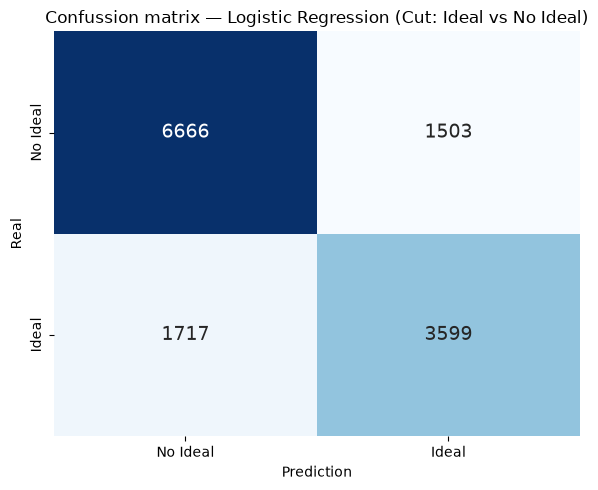

Accuracy:  0.7612
Precision: 0.7054
Recall:    0.6770
F1-score:  0.6909


In [5]:
X_simple = df[["table"]]
y_simple = df["is_ideal"]

model_simple = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler()),
    ("regression", LogisticRegression()),
])

X_train_simple, X_test_simple, y_train_simple, y_test_simple = train_test_split(X_simple, y_simple, test_size=0.25, random_state=777)

model_simple.fit(X_train_simple, y_train_simple) # Here we fit and transform the information
y_pred_simple = model_simple.predict(X_test_simple) # Here we only trasnform and predict

# Metrics
cm = confusion_matrix(y_test_simple, y_pred_simple)
acc = accuracy_score(y_test_simple, y_pred_simple)
prec = precision_score(y_test_simple, y_pred_simple)
rec = recall_score(y_test_simple, y_pred_simple)
f1 = f1_score(y_test_simple, y_pred_simple)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Ideal', 'Ideal'],
            yticklabels=['No Ideal', 'Ideal'],
            cbar=False, annot_kws={'size': 14})
plt.xlabel('Prediction')
plt.ylabel('Real')
plt.title('Confussion matrix — Logistic Regression (Cut: Ideal vs No Ideal)')
plt.tight_layout()
plt.show()
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-score:  {f1:.4f}")

# Two column logistic regression

Lest try to use two columns

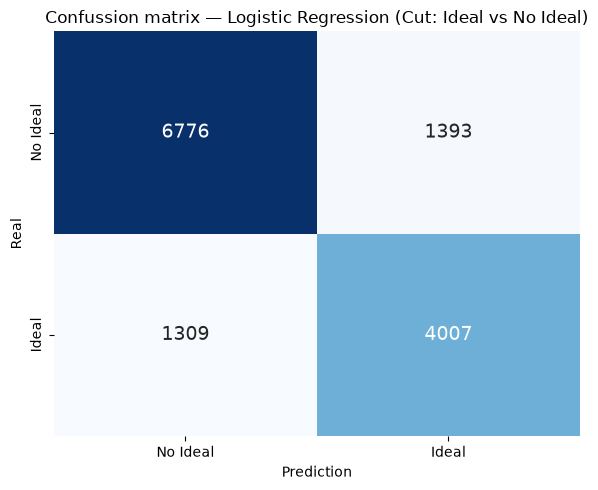

Accuracy:  0.7996
Precision: 0.7420
Recall:    0.7538
F1-score:  0.7479


In [6]:
X_two = df[["table" , "depth"]]
y_two = df["is_ideal"]

model_two = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler()),
    ("regression", LogisticRegression()),
])

X_train_two, X_test_two, y_train_two, y_test_two = train_test_split(X_two, y_two, test_size=0.25, random_state=777)

model_two.fit(X_train_two, y_train_two) # Here we fit and transform the information
y_pred_two = model_two.predict(X_test_two) # Here we only trasnform and predict

# Metrics
cm = confusion_matrix(y_test_two, y_pred_two)
acc = accuracy_score(y_test_two, y_pred_two)
prec = precision_score(y_test_two, y_pred_two)
rec = recall_score(y_test_two, y_pred_two)
f1 = f1_score(y_test_two, y_pred_two)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Ideal', 'Ideal'],
            yticklabels=['No Ideal', 'Ideal'],
            cbar=False, annot_kws={'size': 14})
plt.xlabel('Prediction')
plt.ylabel('Real')
plt.title('Confussion matrix — Logistic Regression (Cut: Ideal vs No Ideal)')
plt.tight_layout()
plt.show()
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-score:  {f1:.4f}")

Lets add more columns so our model can be better!

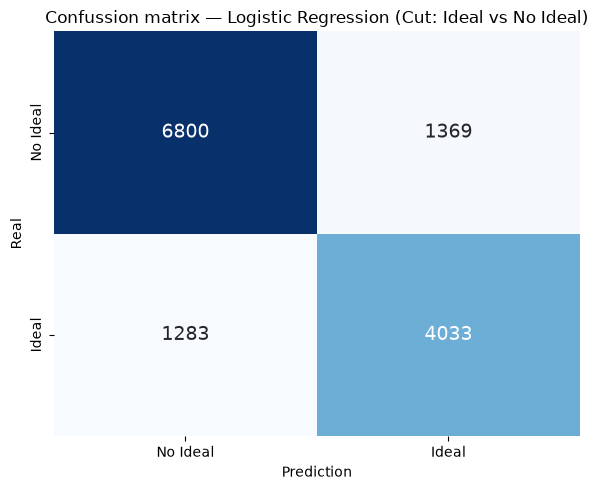

Accuracy:  0.8033
Precision: 0.7466
Recall:    0.7587
F1-score:  0.7526


In [7]:
numeric_cols = ["carat", "depth", "table", "price"]
categoric_cols = []

X = df[numeric_cols + categoric_cols]
y = df["is_ideal"]

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler()),
])

categoric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder()),
])

preprocess = ColumnTransformer([
    ("num", numeric_pipeline, numeric_cols),
    ("cat", categoric_pipeline, categoric_cols)
])

model = Pipeline([
    ("preprocess", preprocess),
    ("regression", LogisticRegression()),
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=777)

model.fit(X_train, y_train) # Here we fit and transform the information
y_pred = model.predict(X_test) # Here we only trasnform and predict

# Metrics
cm = confusion_matrix(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Ideal', 'Ideal'],
            yticklabels=['No Ideal', 'Ideal'],
            cbar=False, annot_kws={'size': 14})
plt.xlabel('Prediction')
plt.ylabel('Real')
plt.title('Confussion matrix — Logistic Regression (Cut: Ideal vs No Ideal)')
plt.tight_layout()
plt.show()
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-score:  {f1:.4f}")